![Decision_Tree_Header](https://raw.githubusercontent.com/satishgunjal/images/master/Decision_Tree_Header.png)

Decision tree algorithm belongs to the family of supervised learning algorithms. Unlike other supervised learning algorithms decision tree can be used to solve regression and classification problems. The goal of decision tree is to create training model that can predict class(single or multi) or value by learning simple decision rules from training data.
Decision tree form a flow chart like structure that's why they are very easy to interpret and understand. It is one of the few ML algorithm where its very easy to visualize and analyze the internal working of algorithm.

Just like flowchart, decision tree contains different types of nodes and branches. Every decision node represent the test on feature and based on the test result it will either form another branch or the leaf node. Every branch represents the decision rule and leaf node represent the final outcome.

![decision tree](https://raw.githubusercontent.com/satishgunjal/images/master/Decision_Tree.png)

Types of decision tree
* Classification decision trees − In this kind of decision trees, the decision variable is categorical. 
* Regression decision trees − In this kind of decision trees, the decision variable is continuous

# Inner Workings Of Decision Tree
* At the root node decision tree selects feature to split the data in two major categories.
* So at the end of root node we have two decision rules and two sub trees
* Data will again be divided in two categories in each sub tree
* This process will continue until every training example is grouped together.
* So at the end of decision tree we end up with leaf node. Which represent the class or a continuous value that we are trying predict

## Criteria To Split The Data
The objective of decision tree is to split the data in such a way that at the end we have different groups of data which has more similarity and less randomness/impurity. In order to achieve this, every split in decision tree must reduce the randomness.
Decision tree uses 'entropy' or 'gini' selection criteria to split the data.
Note: We are going to use sklearn library to test classification and regression. 'entropy' or 'gini' are selection criteria for classifier whereas “mse”, “friedman_mse” and “mae” are selection criteria for regressor.

### Entropy
In order to find the best feature which will reduce the randomness after a split, we can compare the randomness before and after the split for every feature. In the end we choose the feature which will provide the highest reduction in randomness. Formally randomness in data is known as 'Entropy' and difference between the 'Entropy' before and after split is known as 'Information Gain'. Since in case of decision tree we may have multiple branches, information gain formula can be written as,

```
    Information Gain= Entropy(Parent Decision Node)–(Average Entropy(Child Nodes))
```

'i' in below Entropy formula represent the target classes 

   ![entropy_formula](https://raw.githubusercontent.com/satishgunjal/images/master/entropy_formula.png)

So in case of 'Entropy', decision tree will split the data using the feature that provides the highest information gain.

### Gini
In case of gini impurity, we pick a random data point in our dataset. Then randomly classify it according to the class distribution in the dataset. So it becomes very important to know the accuracy of this random classification. Gini impurity gives us the probability of incorrect classification. We’ll determine the quality of the split by weighting the impurity of each branch by how many elements it has. Resulting value is called as 'Gini Gain' or 'Gini Index'. This is what’s used to pick the best split in a decision tree. Higher the Gini Gain, better the split

'i' in below Gini formula represent the target classes 

   ![gini_formula](https://raw.githubusercontent.com/satishgunjal/images/master/gini_formula.png)

So in case of 'gini', decision tree will split the data using the feature that provides the highest gini gain.

### So Which Should We Use?
Gini impurity is computationally faster as it doesn’t require calculating logarithmic functions, though in reality neither metric results in a more accurate tree than the other.

# Advantages Of Decision Tree
* Simple to understand and to interpret. Trees can be visualized.
* Requires little data preparation. Other techniques often require data normalization, dummy variables need to be created and blank values to be removed. Note however that this module does not support missing values.
* Able to handle both numerical and categorical data.
* Able to handle multi-output problems.
* Uses a white box model. Results are easy to interpret.
* Possible to validate a model using statistical tests. That makes it possible to account for the reliability of the model.

# Disadvantages Of Decision Tree
* Decision-tree learners can create over-complex trees that do not generalize the data well. This is called overfitting. Mechanisms such as pruning, setting the minimum number of samples required at a leaf node or setting the maximum depth of the tree are necessary to avoid this problem.
* Decision trees can be unstable because small variations in the data might result in a completely different tree being generated. This problem is mitigated by using decision trees within an ensemble.
* Decision tree learners create biased trees if some classes dominate. It is therefore recommended to balance the dataset prior to fitting with the decision tree.

# Classification Problem Example
For classification exercise we are going to use sklearns iris plant dataset.
Objective is to classify iris flowers among three species (setosa, versicolor or virginica) from measurements of length and width of sepals and petals

## Understanding the IRIS dataset
* iris.DESCR > Complete description of dataset
* iris.data > Data to learn. Each training set is 4 digit array of features. Total 150 training sets
* iris.feature_names > Array of all 4 feature ['sepal length (cm)','sepal width cm)','petal length (cm)','petal width (cm)']
* iris.filename > CSV file name
* iris.target > The classification label. For every training set there is one classification label(0,1,2). Here 0 for setosa, 1 for versicolor and 2 for virginica
* iris.target_names > the meaning of the features. It's an array >> ['setosa', 'versicolor', 'virginica']

From above details its clear that X = 'iris.data' and y= 'iris.target'

![Iris_setosa](https://raw.githubusercontent.com/satishgunjal/images/master/iris_species.png)

<sub><sup>Image from [Machine Learning in R for beginners](https://www.datacamp.com/community/tutorials/machine-learning-in-r)</sup></sub>

## Import Libraries
* pandas: Used for data manipulation and analysis
* numpy : Numpy is the core library for scientific computing in Python. It is used for working with arrays and matrices.
* datasets: Here we are going to use ‘iris’ and 'boston house prices' dataset
* model_selection: Here we are going to use model_selection.train_test_split() for splitting the data
* tree: Here we are going to decision tree classifier and regressor
* graphviz: Is used to export the tree into Graphviz format using the export_graphviz exporter

In [2]:
import pandas as pd
import numpy as np
from sklearn import datasets
from sklearn import model_selection
from sklearn import tree
import graphviz

## Load The Data

In [3]:
iris = datasets.load_iris()
print('Dataset structure= ', dir(iris))

df = pd.DataFrame(iris.data, columns = iris.feature_names)
df['target'] = iris.target
df['flower_species'] = df.target.apply(lambda x : iris.target_names[x]) # Each value from 'target' is used as index to get corresponding value from 'target_names' 

print('Unique target values=',df['target'].unique())

df.sample(5)

Dataset structure=  ['DESCR', 'data', 'feature_names', 'filename', 'target', 'target_names']
Unique target values= [0 1 2]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_species
62,6.0,2.2,4.0,1.0,1,versicolor
67,5.8,2.7,4.1,1.0,1,versicolor
82,5.8,2.7,3.9,1.2,1,versicolor
31,5.4,3.4,1.5,0.4,0,setosa
54,6.5,2.8,4.6,1.5,1,versicolor


Note that, target value 0 = setosa, 1 = versicolor and 2 = virginica

Let visualize the feature values for each type of flower

In [4]:
# label = 0 (setosa)
df[df.target == 0].head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa


In [5]:
# label = 1 (versicolor)
df[df.target == 1].head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_species
50,7.0,3.2,4.7,1.4,1,versicolor
51,6.4,3.2,4.5,1.5,1,versicolor
52,6.9,3.1,4.9,1.5,1,versicolor


In [6]:
# label = 2 (verginica)
df[df.target == 2].head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_species
100,6.3,3.3,6.0,2.5,2,virginica
101,5.8,2.7,5.1,1.9,2,virginica
102,7.1,3.0,5.9,2.1,2,virginica


## Build Machine Learning Model

In [7]:
#Lets create feature matrix X  and y labels
X = df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
y = df[['target']]

print('X shape=', X.shape)
print('y shape=', y.shape)

X shape= (150, 4)
y shape= (150, 1)


### Create Test And Train Dataset
* We will split the dataset, so that we can use one set of data for training the model and one set of data for testing the model
* We will keep 20% of data for testing and 80% of data for training the model
* If you want to learn more about it, please refer [Train Test Split tutorial](https://satishgunjal.com/train_test_split/)

In [8]:
X_train,X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size= 0.2, random_state= 1)
print('X_train dimension= ', X_train.shape)
print('X_test dimension= ', X_test.shape)
print('y_train dimension= ', y_train.shape)
print('y_train dimension= ', y_test.shape)

X_train dimension=  (120, 4)
X_test dimension=  (30, 4)
y_train dimension=  (120, 1)
y_train dimension=  (30, 1)


Now lets train the model using Decision Tree

In [9]:
"""
To obtain a deterministic behaviour during fitting always set value for 'random_state' attribute
Also note that default value of criteria to split the data is 'gini'
"""
cls = tree.DecisionTreeClassifier(random_state= 1)
cls.fit(X_train ,y_train)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=1, splitter='best')

### Testing The Model
* For testing we are going to use the test data only
* Question: Predict the species of 10th, 20th and 29th test example from test data

In [10]:
print('Actual value of species for 10th training example=',iris.target_names[y_test.iloc[10]][0])
print('Predicted value of species for 10th training example=', iris.target_names[cls.predict([X_test.iloc[10]])][0])

print('\nActual value of species for 20th training example=',iris.target_names[y_test.iloc[20]][0])
print('Predicted value of species for 20th training example=', iris.target_names[cls.predict([X_test.iloc[20]])][0])

print('\nActual value of species for 30th training example=',iris.target_names[y_test.iloc[29]][0])
print('Predicted value of species for 30th training example=', iris.target_names[cls.predict([X_test.iloc[29]])][0])

Actual value of species for 10th training example= versicolor
Predicted value of species for 10th training example= versicolor

Actual value of species for 20th training example= versicolor
Predicted value of species for 20th training example= versicolor

Actual value of species for 30th training example= virginica
Predicted value of species for 30th training example= virginica


### Model Score
Check the model score using test data

In [11]:
cls.score(X_test, y_test)

0.9666666666666667

## Visualize The Decision Tree
We will use plot_tree() function from sklearn to plot the tree and then export the tree in Graphviz format using the export_graphviz exporter. Results will be saved in iris_decision_tree.pdf file

[Text(133.92000000000002, 199.32, 'X[3] <= 0.8\ngini = 0.665\nsamples = 120\nvalue = [39, 37, 44]'),
 Text(100.44000000000001, 163.07999999999998, 'gini = 0.0\nsamples = 39\nvalue = [39, 0, 0]'),
 Text(167.40000000000003, 163.07999999999998, 'X[3] <= 1.65\ngini = 0.496\nsamples = 81\nvalue = [0, 37, 44]'),
 Text(66.96000000000001, 126.83999999999999, 'X[2] <= 4.95\ngini = 0.18\nsamples = 40\nvalue = [0, 36, 4]'),
 Text(33.480000000000004, 90.6, 'gini = 0.0\nsamples = 35\nvalue = [0, 35, 0]'),
 Text(100.44000000000001, 90.6, 'X[0] <= 6.05\ngini = 0.32\nsamples = 5\nvalue = [0, 1, 4]'),
 Text(66.96000000000001, 54.359999999999985, 'X[3] <= 1.55\ngini = 0.5\nsamples = 2\nvalue = [0, 1, 1]'),
 Text(33.480000000000004, 18.119999999999976, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(100.44000000000001, 18.119999999999976, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(133.92000000000002, 54.359999999999985, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(267.8400000000000

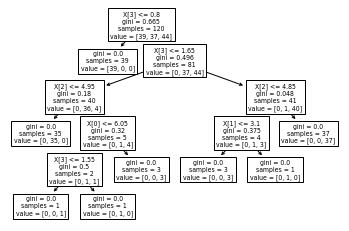

In [12]:
tree.plot_tree(cls) 

In [13]:
dot_data = tree.export_graphviz(cls, out_file=None) 
graph = graphviz.Source(dot_data) 
graph.render("iris_decision_tree") 

'iris_decision_tree.pdf'

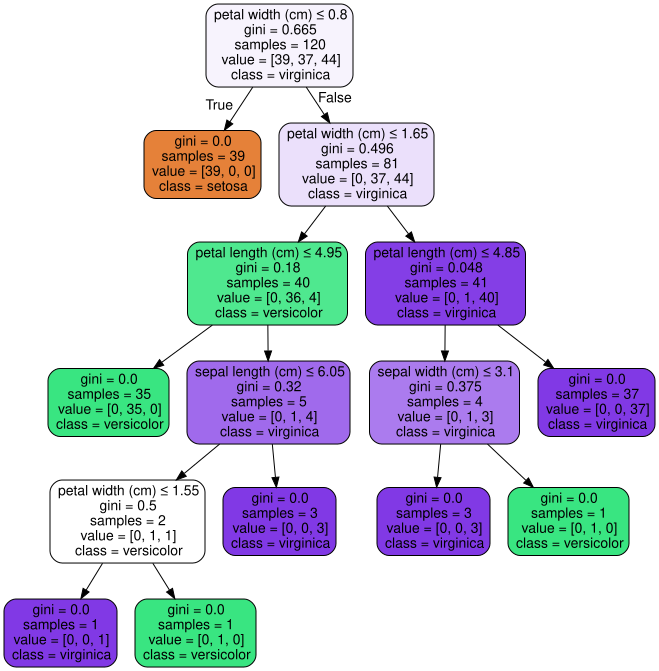

In [14]:
dot_data = tree.export_graphviz(cls, out_file=None, 
                      feature_names=iris.feature_names,  
                      class_names=iris.target_names,  
                      filled=True, rounded=True,  
                      special_characters=True)  
graph = graphviz.Source(dot_data)  
graph 

# Regression Problem Example
For regression exercise we are going to use sklearns Boston house prices dataset
Objective is to predict house price based on available data

## Understanding the Boston house dataset
* boston.DESCR > Complete description of dataset
* boston.data > Data to learn. There are 13 features, Median Value (attribute 14) is usually the target. Total 506 training sets
    - CRIM     per capita crime rate by town
    - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
    - INDUS    proportion of non-retail business acres per town
    - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
    - NOX      nitric oxides concentration (parts per 10 million)
    - RM       average number of rooms per dwelling
    - AGE      proportion of owner-occupied units built prior to 1940
    - DIS      weighted distances to five Boston employment centres
    - RAD      index of accessibility to radial highways
    - TAX      full-value property-tax rate per USD 10,000
    - PTRATIO  pupil-teacher ratio by town
    - B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
    - LSTAT    % lower status of the population
    - MEDV     Median value of owner-occupied homes in USD 1000's
* boston.feature_names > Array of all 13 features ['CRIM' 'ZN' 'INDUS' 'CHAS' 'NOX' 'RM' 'AGE' 'DIS' 'RAD' 'TAX' 'PTRATIO'
 'B' 'LSTAT']
* boston.filename > CSV file name
* boston.target > The price valueis in $1000’s

From above details its clear that X = 'boston.data' and y= 'boston.target'

In [15]:
boston = datasets.load_boston()
print('Dataset structure= ', dir(boston))

df = pd.DataFrame(boston.data, columns = boston.feature_names)
df['target'] = boston.target

df.sample(5)

Dataset structure=  ['DESCR', 'data', 'feature_names', 'filename', 'target']


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,target
210,0.17446,0.0,10.59,1.0,0.489,5.960,92.1,3.8771,4.0,277.0,18.6,393.25,17.27,21.7
469,13.07510,0.0,18.10,0.0,0.580,5.713,56.7,2.8237,24.0,666.0,20.2,396.90,14.76,20.1
450,6.71772,0.0,18.10,0.0,0.713,6.749,92.6,2.3236,24.0,666.0,20.2,0.32,17.44,13.4
492,0.11132,0.0,27.74,0.0,0.609,5.983,83.5,2.1099,4.0,711.0,20.1,396.90,13.35,20.1
371,9.23230,0.0,18.10,0.0,0.631,6.216,100.0,1.1691,24.0,666.0,20.2,366.15,9.53,50.0


## Build Machine Learning Model

In [16]:
#Lets create feature matrix X  and y labels
X = df[['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']]
y = df[['target']]

print('X shape=', X.shape)
print('y shape=', y.shape)

X shape= (506, 13)
y shape= (506, 1)


### Create Test And Train Dataset
* We will split the dataset, so that we can use one set of data for training the model and one set of data for testing the model
* We will keep 20% of data for testing and 80% of data for training the model
* If you want to learn more about it, please refer [Train Test Split tutorial](https://satishgunjal.com/train_test_split/)

In [17]:
X_train,X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size= 0.2, random_state= 1)
print('X_train dimension= ', X_train.shape)
print('X_test dimension= ', X_test.shape)
print('y_train dimension= ', y_train.shape)
print('y_train dimension= ', y_test.shape)

X_train dimension=  (404, 13)
X_test dimension=  (102, 13)
y_train dimension=  (404, 1)
y_train dimension=  (102, 1)


Now lets train the model using Decision Tree

In [18]:
"""
To obtain a deterministic behaviour during fitting always set value for 'random_state' attribute
To keep the tree simple I am using max_depth = 3
Also note that default value of criteria to split the data is 'mse' (mean squared error)
mse is equal to variance reduction as feature selection criterion and minimizes the L2 loss using the mean of each terminal node
"""
dtr = tree.DecisionTreeRegressor(max_depth= 3,random_state= 1)
dtr.fit(X_train ,y_train)

DecisionTreeRegressor(ccp_alpha=0.0, criterion='mse', max_depth=3,
                      max_features=None, max_leaf_nodes=None,
                      min_impurity_decrease=0.0, min_impurity_split=None,
                      min_samples_leaf=1, min_samples_split=2,
                      min_weight_fraction_leaf=0.0, presort='deprecated',
                      random_state=1, splitter='best')

### Testing The Model
* For testing we are going to use the test data only
* Question: predict the values for every test set in test data

In [19]:
predicted_price= pd.DataFrame(dtr.predict(X_test), columns=['Predicted Price'])
actual_price = pd.DataFrame(y_test, columns=['target'])
actual_price = actual_price.reset_index(drop=True) # Drop the index so that we can concat it, to create new dataframe
df_actual_vs_predicted = pd.concat([actual_price,predicted_price],axis =1)
df_actual_vs_predicted.T

,0,1,2,3,4,5,6,7,8,9,...,92,93,94,95,96,97,98,99,100,101
target,28.200000,23.900000,16.600000,22.000000,20.800000,23.000000,27.900000,14.500000,21.500000,22.600000,...,13.600,22.900000,10.900000,18.900000,22.400000,22.900000,44.800000,21.700000,10.200000,15.400
Predicted Price,26.834266,26.834266,17.769048,26.834266,19.992727,19.992727,26.834266,19.992727,17.769048,26.834266,...,12.532,19.992727,19.992727,19.992727,26.834266,26.834266,45.385714,19.992727,19.992727,12.532


### Model Score
Check the model score using test data

In [20]:
dtr.score(X_test, y_test)

0.6647121948539862

## Visualize The Decision Tree
We will use plot_tree() function from sklearn to plot the tree and then export the tree in Graphviz format using the export_graphviz exporter. Results will be saved in boston_decision_tree.pdf file

[Text(167.4, 190.26, 'X[12] <= 9.725\nmse = 80.781\nsamples = 404\nvalue = 22.522'),
 Text(83.7, 135.9, 'X[5] <= 7.437\nmse = 73.352\nsamples = 169\nvalue = 29.659'),
 Text(41.85, 81.53999999999999, 'X[7] <= 1.485\nmse = 40.799\nsamples = 147\nvalue = 27.465'),
 Text(20.925, 27.180000000000007, 'mse = 0.0\nsamples = 4\nvalue = 50.0'),
 Text(62.775000000000006, 27.180000000000007, 'mse = 27.338\nsamples = 143\nvalue = 26.834'),
 Text(125.55000000000001, 81.53999999999999, 'X[5] <= 8.589\nmse = 43.794\nsamples = 22\nvalue = 44.318'),
 Text(104.625, 27.180000000000007, 'mse = 20.808\nsamples = 21\nvalue = 45.386'),
 Text(146.475, 27.180000000000007, 'mse = 0.0\nsamples = 1\nvalue = 21.9'),
 Text(251.10000000000002, 135.9, 'X[12] <= 16.085\nmse = 23.162\nsamples = 235\nvalue = 17.39'),
 Text(209.25, 81.53999999999999, 'X[2] <= 3.985\nmse = 9.361\nsamples = 118\nvalue = 20.343'),
 Text(188.32500000000002, 27.180000000000007, 'mse = 20.712\nsamples = 8\nvalue = 25.162'),
 Text(230.175, 27.18

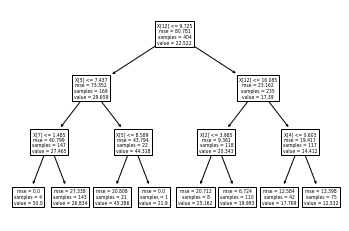

In [21]:
tree.plot_tree(dtr) 

In [22]:
dot_data = tree.export_graphviz(dtr, out_file=None) 
graph = graphviz.Source(dot_data) 
graph.render("boston_decision_tree") 

'boston_decision_tree.pdf'

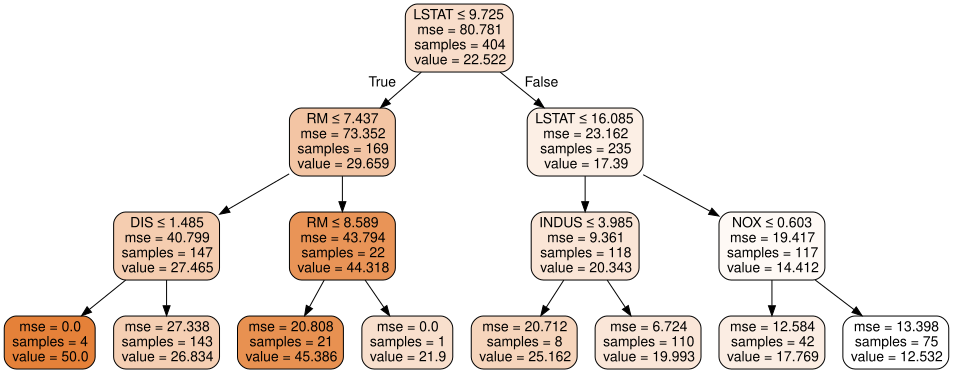

In [23]:
dot_data = tree.export_graphviz(dtr, out_file=None, 
                      feature_names=boston.feature_names,  
                      filled=True, rounded=True,  
                      special_characters=True)  
graph = graphviz.Source(dot_data)  
graph 